In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
train.shape

(1460, 81)

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
train.duplicated().sum()

np.int64(0)

## Пропуски

In [6]:
quantitative = train.select_dtypes(include=['int64', 'float64']).columns.drop(['Id', 'SalePrice'])
categorical = train.select_dtypes(include=['str']).columns

print("Quantitative:")
print(quantitative)

print()

print("Categorical:")
print(categorical)

Quantitative:
Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='str')

Categorical:
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heati

In [7]:
print('Пропуски в категориальных: ', train[categorical].columns[train[categorical].isna().sum() > 0])
print('Пропуски в количественных: ', train[quantitative].columns[train[quantitative].isna().sum() > 0])

Пропуски в категориальных:  Index(['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC',
       'Fence', 'MiscFeature'],
      dtype='str')
Пропуски в количественных:  Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'], dtype='str')


In [8]:
categorical_0 = ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC',
       'Fence', 'MiscFeature']
quantitative_0 = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

In [9]:
train[quantitative_0].isna().sum()

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

In [10]:
train[quantitative_0].describe()

,LotFrontage,MasVnrArea,GarageYrBlt
count,1201.000000,1452.000000,1379.000000
mean,70.049958,103.685262,1978.506164
std,24.284752,181.066207,24.689725
min,21.000000,0.000000,1900.000000
25%,59.000000,0.000000,1961.000000
50%,69.000000,0.000000,1980.000000
75%,80.000000,166.000000,2002.000000
max,313.000000,1600.000000,2010.000000


In [11]:
train[train['GarageYrBlt'].isna()][
    ['GarageYrBlt', 'GarageType', 'GarageCars', 'GarageArea']].head(20)

,GarageYrBlt,GarageType,GarageCars,GarageArea
39,NaN,NaN,0,0
48,NaN,NaN,0,0
78,NaN,NaN,0,0
88,NaN,NaN,0,0
89,NaN,NaN,0,0
99,NaN,NaN,0,0
108,NaN,NaN,0,0
125,NaN,NaN,0,0
127,NaN,NaN,0,0
140,NaN,NaN,0,0


In [12]:
# Решил заполнить медианой по нескольким причинам:
#   1. Сам признак логически зависит от округа в котором расположен дом, поэтому будем групировать по округам
#   2. Выбрал медиану, т.к. она меньше всего зависит от выбросов, которые есть
train['LotFrontage'] = train['LotFrontage'].fillna(
    train.groupby('Neighborhood')['LotFrontage'].transform('median'))
test['LotFrontage'] = test['LotFrontage'].fillna(
    test.groupby('Neighborhood')['LotFrontage'].transform('median'))


# Здесь пропуски означают в целом отсутствие объекта, поэтому просто 0 вставил
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)

train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)

In [13]:
train[quantitative_0].isna().sum()

LotFrontage    0
MasVnrArea     0
GarageYrBlt    0
dtype: int64

In [14]:
print(train[categorical_0].isna().sum())

Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [15]:
# Здесь пропуски логично заполнить "Ничем", т.к. они буквально и означают отсутствие объекта
train[categorical_0] = train[categorical_0].fillna('None')
test[categorical_0] = test[categorical_0].fillna('None')

In [16]:
print('Всего пропусков: ', sum(train.isna().sum() > 0))

Всего пропусков:  0


### Пропуски в тесте

In [17]:
quantitative_test = test.select_dtypes(include=['int64', 'float64']).columns
categorical_test = test.select_dtypes(include=['str', 'object']).columns

print('Пропуски в категориальных: ', test[categorical_test].columns[test[categorical_test].isna().sum() > 0])
print('Пропуски в количественных: ', test[quantitative_test].columns[test[quantitative_test].isna().sum() > 0])

Пропуски в категориальных:  Index(['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual',
       'Functional', 'SaleType'],
      dtype='str')
Пропуски в количественных:  Index(['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
       'BsmtHalfBath', 'GarageCars', 'GarageArea'],
      dtype='str')


In [18]:
categorical_0_test = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual',
       'Functional', 'SaleType']
quantitative_0_test = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
       'BsmtHalfBath', 'GarageCars', 'GarageArea']

# По тому же принципу что и в трейне
test[quantitative_0_test] = test[quantitative_0_test].fillna(0)

test[['Utilities', 'Exterior2nd', 'KitchenQual']] = test[['Utilities', 'Exterior2nd', 'KitchenQual']].fillna('Unknown')
for col in ['MSZoning', 'Exterior1st', 'Functional', 'SaleType']:
       test[col] = test[col].fillna(test[col].mode()[0])

In [19]:
print('Всего пропусков: ', sum(test.isna().sum() > 0))

print('Пропуски в категориальных: ', test[categorical_test].columns[test[categorical_test].isna().sum() > 0])
print('Пропуски в количественных: ', test[quantitative_test].columns[test[quantitative_test].isna().sum() > 0])

Всего пропусков:  0
Пропуски в категориальных:  Index([], dtype='str')
Пропуски в количественных:  Index([], dtype='str')


### Масштабирование и OHE

In [20]:
X_train = train.drop(['SalePrice', 'Id'], axis=1)
y_train = np.log1p(train['SalePrice'])
X_test = test.drop('Id', axis=1)

In [21]:
sum(X_train.isna().sum())

0

In [22]:
'''X_train_dum = pd.get_dummies(X_train)

norm = MinMaxScaler()
X_train_enc = norm.fit_transform(X_train_dum)
X_train = pd.DataFrame(data=X_train_enc, columns=X_train_dum.columns)
X_train.head()'''

'X_train_dum = pd.get_dummies(X_train)\n\nnorm = MinMaxScaler()\nX_train_enc = norm.fit_transform(X_train_dum)\nX_train = pd.DataFrame(data=X_train_enc, columns=X_train_dum.columns)\nX_train.head()'

In [23]:
sum(X_train.isna().sum())

0

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

ct = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), quantitative),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)])

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)
#X_train_dum = pd.get_dummies(X_train)
#X_test_dum = pd.get_dummies(X_test)

## Бейз

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
pred1 = lr.predict(X_train)
print(root_mean_squared_error(y_train, pred1))

0.09452506815816167


In [ ]:
#sub1 = lr.predict(X_test)
sub = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': lr.predict(X_test)
})

sub

,Id,SalePrice
0,1461,11.708461
1,1462,12.022009
2,1463,12.117594
3,1464,12.223283
4,1465,12.176374
...,...,...
1454,2915,11.337657
1455,2916,11.358906
1456,2917,12.076131
1457,2918,11.646683


In [ ]:
sub.to_csv('sub.csv', index=False)

## Эксперименты

In [38]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, max_iter=10000)
lasso.fit(X_train, y_train)
pred2 = lasso.predict(X_train)
print(root_mean_squared_error(y_train, pred2))

0.11490124047759671


In [39]:
from sklearn.linear_model import RidgeCV

lasso = RidgeCV(cv=5)
lasso.fit(X_train, y_train)
pred3 = lasso.predict(X_train)
print(root_mean_squared_error(y_train, pred3))

0.11652566967128843


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

params = {
    "n_estimators": [500, 800, 1200, 1600],
    "max_depth": [None, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 3, 5, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": [0.3, 0.5, 0.7, 1.0],
    "bootstrap": [True],
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params,
    n_iter=80,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=2,
    verbose=1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(-search.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


{'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20, 'bootstrap': True}
0.1381871576116565


In [ ]:
from xgboost.sklearn import XGBRegressor

## Отбор признаков

In [29]:
print('Кол-во качественных:', len(categorical))
print('Кол-во количественных:', len(quantitative))

Кол-во качественных: 43
Кол-во количественных: 36


In [30]:
quant_corr = train[quantitative].corr('pearson')
abs(quant_corr) <= 0.5

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
MSSubClass,False,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
LotFrontage,True,False,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
LotArea,True,True,False,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
OverallQual,True,True,True,False,True,False,False,True,True,True,...,False,True,True,True,True,True,True,True,True,True
OverallCond,True,True,True,True,False,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
YearBuilt,True,True,True,False,True,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
YearRemodAdd,True,True,True,False,True,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
MasVnrArea,True,True,True,True,True,True,True,False,True,True,...,True,True,True,True,True,True,True,True,True,True
BsmtFinSF1,True,True,True,True,True,True,True,True,False,True,...,True,True,True,True,True,True,True,True,True,True
BsmtFinSF2,True,True,True,True,True,True,True,True,True,False,...,True,True,True,True,True,True,True,True,True,True


<Axes: >

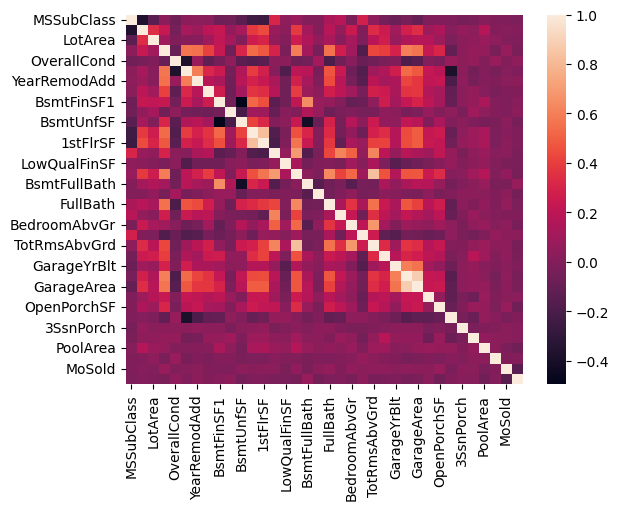

In [31]:
sns.heatmap(train[quantitative].corr('pearson'))